# Agricultural Intensity and Nitrate Contamination in Iowa (2010–2017)

## Introduction

Iowa is one of the most agriculturally intensive states in the United States. Large areas of corn and soybean cultivation, along with smaller areas of oats production, require substantial fertilizer application, especially nitrogen-based fertilizers. While fertilizers increase crop productivity, excess nitrogen can be converted to nitrate in soils and transported through runoff or leaching into rivers and groundwater systems.

Nitrate contamination has become an environmental and public health concern. Elevated nitrate concentrations can degrade aquatic ecosystems and, in drinking water supplies, may exceed the EPA safety standard of 10 mg/L.

## Abstract

This project investigates the relationship between agricultural intensity and nitrate contamination in Iowa from 2010–2017. Using USDA crop acreage data and nitrate measurements from the Water Quality Portal, we analyze spatial and temporal patterns in surface water and groundwater. County-level maps, time series, and exploratory analyses are used to evaluate whether higher agricultural intensity is associated with elevated nitrate concentrations. Results suggest spatial variability across counties and differences between surface and groundwater dynamics. These findings contribute to understanding how agricultural practices may influence water quality in Iowa.

#Why We Chose This Topic

We chose this topic because Iowa provides a strong case study for understanding how agricultural practices may influence water quality. The state has both high crop intensity and documented nitrate contamination in water systems.

Studying this relationship at the county level allows us to evaluate spatial variation across Iowa and determine whether counties with greater agricultural intensity exhibit higher nitrate concentrations in surface water and groundwater.

## Research Question

From 2010–2017, are Iowa counties with higher agricultural intensity associated with higher nitrate concentrations in surface water and groundwater?

We also ask whether surface water and groundwater show similar spatial and temporal patterns, and whether groundwater nitrate frequently exceeds the EPA drinking water standard of 10 mg/L.

## Hypothesis

We hypothesize that counties with higher corn and soybean acreage will exhibit higher average nitrate concentrations, particularly in surface water due to runoff processes.

We also expect groundwater nitrate concentrations to be more stable over time but potentially show exceedances of the EPA 10 mg/L standard in agriculturally intensive regions.

## Background and Prior Research

Nitrate contamination is commonly observed in agricultural regions because nitrogen fertilizer applied to cropland can move into rivers through runoff or leach into groundwater. A national summary by the U.S. Geological Survey (USGS) reports that nitrate levels are frequently elevated in streams and groundwater in areas dominated by row-crop agriculture (USGS, 2010). This provides scientific support for examining nitrate patterns in Iowa, a highly agricultural state.

Nitrate is regulated in drinking water due to health concerns. Under federal regulation, the maximum contaminant level (MCL) for nitrate is **10 mg/L (as nitrogen)**. In this project, we use this threshold when evaluating groundwater exceedances (eCFR, n.d.).

Iowa has formally addressed nutrient pollution through the Iowa Nutrient Reduction Strategy (2013), which identifies agricultural runoff as a major contributor to nitrogen entering waterways. In addition, a regional analysis covering **2008–2017** found that elevated nitrate concentrations increased treatment challenges for water utilities in agriculturally intensive areas (Vedachalam, 2018).

In this project, nitrate measurements are obtained from the Water Quality Portal, which compiles monitoring data from USGS, EPA, and partner agencies (Water Quality Portal, n.d.). Together, these sources provide scientific, regulatory, and policy context for analyzing agricultural intensity and nitrate contamination in Iowa between 2010 and 2017.

## Data

To investigate the relationship between agriculture and nitrate contamination, we combine crop acreage data with surface water and groundwater nitrate measurements. All datasets are restricted to Iowa counties from 2010–2017 to ensure temporal consistency.

#What We Will Do in This Project

In this project, we will:

1. Measure agricultural intensity using county-level crop acreage data.
2. Analyze surface water and groundwater nitrate concentrations from 2010 to 2017.
3. Create maps and time series to explore spatial and temporal patterns.
4. Test whether counties with higher agricultural acreage show higher nitrate levels.
5. Evaluate how often groundwater nitrate exceeds the EPA standard of 10 mg/L.

Through these analyses, we aim to build a clear, data-driven story about agricultural intensity and water quality in Iowa.

## Data Sources

This project uses four main datasets:

1. Crop Acreage Data (USDA)
   - County-level acreage of corn, oats, and soybeans
   - Used to measure agricultural intensity

2. Surface Water Nitrate Data (Water Quality Portal)
   - Nitrate concentration measurements from rivers and streams
   - Used to analyze surface water quality

3. Groundwater Nitrate Data (Water Quality Portal)
   - Nitrate concentration measurements from groundwater wells
   - Used to evaluate drinking water risks

4. U.S. Census County Boundaries (2024 TIGER/Line)
   - County shapefile for spatial mapping
   - Used to create choropleth maps

We focus only on Iowa counties from 2010 to 2017.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
import os
os.makedirs('figures', exist_ok=True)

In [3]:
df_crop = pd.read_csv("data/raw/corn_oats_soyabeans.csv")

df_water = pd.read_csv("data/raw/water_nitrate.csv")

df_ground = pd.read_csv("data/raw/groundwater_nitrate.csv")

gdf_county = gpd.read_file("data/shapefiles/tl_2024_us_county.shp")

/var/folders/tg/tkjw1mdx3q955yn6m2bwwxww0000gn/T/ipykernel_45675/304800013.py:3: DtypeWarning: Columns (9,10,11,12,15,17,19,21,24,25,26,27,28,34,38,41,43,45,47,51,59,73,74,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df_water = pd.read_csv("data/raw/water_nitrate.csv")


# Preparing Crop Data (Agricultural Intensity)

The USDA crop dataset contains acreage information for corn, oats, and soybeans at the county level.

Since our project focuses on agricultural intensity in Iowa from 2010 to 2017, we will:

- Keep only Iowa counties
- Keep only county-level records
- Keep study years (2010–2017)
- Clean acreage values
- Standardize county names
- Create a county–year dataset

We define agricultural intensity mainly using **corn and soybean acreage**, because:

- Corn and soybeans dominate Iowa agriculture.
- They are reported consistently across counties and years.
- Oats data is incomplete in some years and counties.

Therefore, our main intensity variable will be:

Corn acreage + Soybean acreage

In [4]:
df_crop = pd.read_csv("data/raw/corn_oats_soyabeans.csv")

df_crop = df_crop[df_crop["State"] == "IOWA"]

df_crop = df_crop[df_crop["Geo Level"] == "COUNTY"]

df_crop["Year"] = pd.to_numeric(df_crop["Year"], errors="coerce")
df_crop = df_crop[(df_crop["Year"] >= 2010) & (df_crop["Year"] <= 2017)]

Cleaning County Names and Acreage Values

Before constructing agricultural intensity, we standardize county names and clean acreage values.

This is necessary because:

* County names must match the shapefile later.
* Acreage values are stored as formatted text with commas.
* Aggregate rows such as “OTHER COUNTIES” should not be included.

In [5]:
df_crop["County"] = df_crop["County"].astype(str).str.strip().str.upper()
df_crop = df_crop[df_crop["County"] != "OTHER COUNTIES"]
df_crop = df_crop[df_crop["County"] != ""]


df_crop["Value"] = df_crop["Value"].astype(str).str.replace(",", "", regex=False)
df_crop["Value"] = pd.to_numeric(df_crop["Value"], errors="coerce")

The USDA dataset contains multiple reporting categories. Since agricultural intensity is based on land under cultivation, we keep only planted acreage records.

In [6]:
df_crop = df_crop[df_crop["Data Item"].astype(str).str.contains("ACRES PLANTED", na=False)]

This ensures that our intensity variable reflects land area, not yield or production.

In [7]:

df_crop["Commodity"] = df_crop["Commodity"].astype(str).str.strip().str.upper()

crop_pivot = df_crop.pivot_table(
    index=["County", "Year"],
    columns="Commodity",
    values="Value",
    aggfunc="sum"
).reset_index()

After pivoting, each row represents one county in one year, and columns represent crop acreage by commodity.

Some crops (such as oats) are not reported consistently across all counties and years.

To prevent calculation errors, we replace missing values with zero.

In [8]:
crop_cols = [c for c in crop_pivot.columns if c not in ["County", "Year"]]
crop_pivot[crop_cols] = crop_pivot[crop_cols].fillna(0)

We define agricultural intensity primarily using corn and soybean acreage because:

* Corn and soybeans dominate Iowa agriculture.
* They are consistently reported across counties and years.
* Oats acreage is smaller and sometimes incomplete.

In [9]:
corn_col = [c for c in crop_pivot.columns if "CORN" in str(c).upper()][0]
soy_col  = [c for c in crop_pivot.columns if "SOY"  in str(c).upper()][0]


crop_pivot["intensity_acre"] = crop_pivot[corn_col] + crop_pivot[soy_col]


crop_pivot["total_acre"] = crop_pivot[crop_cols].sum(axis=1)


print("Pivot crop columns:", crop_cols)
print("Using corn column:", corn_col)
print("Using soy column:", soy_col)

crop_pivot.head()

Pivot crop columns: ['CORN', 'OATS', 'SOYBEANS']
Using corn column: CORN
Using soy column: SOYBEANS


Commodity,County,Year,CORN,OATS,SOYBEANS,intensity_acre,total_acre
0,ADAIR,2010,105500.0,4300.0,102000.0,207500.0,211800.0
1,ADAIR,2011,112000.0,2700.0,103500.0,215500.0,218200.0
2,ADAIR,2012,110000.0,0.0,105500.0,215500.0,215500.0
3,ADAIR,2013,113000.0,4300.0,104000.0,217000.0,221300.0
4,ADAIR,2014,109500.0,0.0,106000.0,215500.0,215500.0


The output confirms that:

* CORN, OATS, and SOYBEANS columns are present.
* Corn and soy columns are correctly identified.
* Agricultural intensity is calculated as expected.

For example, Adair County shows consistent corn and soybean acreage values across years.

Most years contain 100 counties, with slight reductions in 2015 and 2017.

This suggests minor reporting gaps but overall strong coverage for the study period.

To make sure our filtering and cleaning steps worked correctly, we check one county. Here, we look at Adair County and examine its crop records across years.



Now we have a clean county–year crop dataset for Iowa (2010–2017).  Each row represents one county in one year, with corn, oats, soybeans acreage, and a `total_acre` column that measures overall agricultural intensity.

## Preparing Nitrate Data (Surface Water and Groundwater)

Now that we have constructed our agricultural intensity dataset, we turn to the environmental side of the project — nitrate contamination.

The nitrate datasets come from the Water Quality Portal and contain individual water quality measurements. Each row represents a single sampling event at a specific location and date.

However, these datasets contain many metadata columns that are not directly relevant to our analysis. Our goal in this section is to:

* Keep only nitrate measurements
* Extract the sampling year
* Keep nitrate concentration values
* Preserve latitude and longitude coordinates
* Prepare the data for spatial assignment to counties

At this stage, the nitrate data is still point-based and not yet linked to counties.

# Cleaning and Filtering the Raw Surface Water Dataset
We first reload the dataset fresh and apply filters so that we keep only relevant rows for this project.

In [10]:
df_water = pd.read_csv("data/raw/water_nitrate.csv", low_memory=False)

df_water["year"] = pd.to_datetime(df_water["ActivityStartDate"], errors="coerce").dt.year
df_water = df_water[df_water["year"].between(2010, 2017)]

df_water = df_water[df_water["CharacteristicName"].str.contains("Nitrate", case=False, na=False)]

df_water = df_water[df_water["ActivityMediaSubdivisionName"] == "Surface Water"]


df_water["nitrate"] = pd.to_numeric(df_water["ResultMeasureValue"], errors="coerce")
df_water = df_water.dropna(subset=["nitrate"])


df_water = df_water.dropna(subset=[
    "ActivityLocation/LatitudeMeasure",
    "ActivityLocation/LongitudeMeasure"
])

df_water[["year","nitrate",
          "ActivityLocation/LatitudeMeasure",
          "ActivityLocation/LongitudeMeasure"]].head()

,year,nitrate,ActivityLocation/LatitudeMeasure,ActivityLocation/LongitudeMeasure
44328,2010,8.60,41.950380,-93.551013
44337,2010,9.40,43.125635,-93.123303
44338,2010,0.74,41.424689,-93.587285
44345,2010,8.40,43.065854,-93.616067
44347,2010,4.60,42.358258,-90.534857


After these steps, we have:

* Restricted the dataset to nitrate measurements only
* Limited it to 2010–2017
* Ensured nitrate values are numeric
* Removed rows with missing concentration values
* Removed rows without spatial coordinates

From the preview table, we can see that each row now contains:
* year (extracted from sampling date)
* nitrate concentration
* Latitude and longitude of the sampling location

At this point, the data is clean but still point-based — we do not yet know which county each sample belongs to.

Converting Measurements into Spatial Points

To assign nitrate measurements to counties, we first convert the dataset into a GeoDataFrame where each row becomes a spatial point.

In [11]:
gdf_water = gpd.GeoDataFrame(
    df_water,
    geometry=gpd.points_from_xy(
        df_water["ActivityLocation/LongitudeMeasure"],
        df_water["ActivityLocation/LatitudeMeasure"]
    ),
    crs="EPSG:4326"
)

Now each nitrate measurement is a geographic point with a defined coordinate reference system.

This step is essential because spatial joins require geometric objects, not just numeric latitude and longitude columns.

Loading Iowa County Boundaries

Next, we load the county shapefile and filter it to Iowa only.

In [12]:

gdf_county = gpd.read_file("data/shapefiles/tl_2024_us_county.shp")
gdf_county = gdf_county[gdf_county["STATEFP"] == "19"]

By filtering STATEFP == "19", we isolate Iowa counties using the official FIPS code for Iowa.

Now we have Iowa county polygons that we can use for spatial matching.

Assigning Surface Water Measurements to Counties

We now perform a spatial join to assign each nitrate sampling point to the county polygon it falls within.

In [13]:
gdf_water = gpd.sjoin(
    gdf_water.to_crs(gdf_county.crs),
    gdf_county[["NAME", "geometry"]],
    how="inner",
    predicate="within"
)

After this step:
* Every nitrate measurement has been assigned to a county (NAME).
* Each point is now spatially linked to a county polygon.
* We can begin aggregating nitrate data at the county level.

This is a critical step in the project because it allows us to connect environmental measurements with agricultural intensity at the same geographic scale.

Aggregating Surface Water Nitrate to County–Year Level

Since there are multiple nitrate measurements within each county each year, we compute the average nitrate concentration for each county-year.

In [14]:
water_county_year = (
    gdf_water.groupby(["NAME", "year"])["nitrate"]
    .mean()
    .reset_index()
)

water_county_year.head()

,NAME,year,nitrate
0,Adair,2010,3.340
1,Adair,2011,3.160
2,Adair,2012,0.060
3,Adair,2015,0.866
4,Adair,2016,0.500


Now each row represents:

One county (NAME)
One year (year)
The mean surface water nitrate concentration
This structure matches our crop dataset format (county–year), meaning we are now ready to merge agricultural intensity with nitrate contamination.

# Preparing Groundwater Nitrate Data
The groundwater nitrate dataset contains nitrate measurements collected from wells across Iowa.
Similar to the surface water dataset, each record includes:

* sampling date
* nitrate concentration
* latitude and longitude

However, county names are not directly provided.
To compare groundwater nitrate with county-level crop acreage, we must assign each measurement to an Iowa county using spatial location.

We will follow the same workflow used for surface water:

* Extract sampling year
* Keep nitrate measurements only
* Remove missing values and coordinates
* Convert to spatial points
* Spatially join with Iowa counties
* Aggregate to county–year averages

# Cleaning Groundwater Nitrate Measurements
After preparing the surface water dataset, we now repeat a similar process for groundwater nitrate measurements.

Groundwater is especially important in our analysis because it is directly connected to drinking water systems. Unlike surface water, which reflects river and stream conditions, groundwater contamination has more direct public health implications.

Our goal in this section is to:
* Extract the sampling year
* Restrict the data to 2010–2017
* Keep only nitrate measurements
* Keep only groundwater samples
* Convert nitrate values to numeric
* Remove missing values and missing coordinates

In [15]:
df_ground = pd.read_csv("data/raw/groundwater_nitrate.csv", low_memory=False)

df_ground["year"] = pd.to_datetime(df_ground["ActivityStartDate"], errors="coerce").dt.year
df_ground = df_ground[df_ground["year"].between(2010, 2017)]

df_ground = df_ground[df_ground["CharacteristicName"].str.contains("Nitrate", case=False, na=False)]

df_ground = df_ground[df_ground["ActivityMediaSubdivisionName"] == "Groundwater"]

df_ground["nitrate"] = pd.to_numeric(df_ground["ResultMeasureValue"], errors="coerce")
df_ground = df_ground.dropna(subset=["nitrate"])

df_ground = df_ground.dropna(subset=[
    "ActivityLocation/LatitudeMeasure",
    "ActivityLocation/LongitudeMeasure"
])

df_ground[["year","nitrate",
           "ActivityLocation/LatitudeMeasure",
           "ActivityLocation/LongitudeMeasure"]].head()

,year,nitrate,ActivityLocation/LatitudeMeasure,ActivityLocation/LongitudeMeasure
5172,2010,8.7,42.821380,-95.969960
5173,2010,7.8,42.821060,-95.971080
5174,2010,8.5,42.822280,-95.969660
5175,2010,6.8,41.860092,-95.599873
5176,2010,8.8,42.821362,-95.969991


* The year column has been extracted correctly.
* Nitrate values are numeric.
* Latitude and longitude are present for each sample.
* Each row now represents a valid groundwater nitrate measurement taken between 2010 and 2017.

At this point, the data is clean but still not assigned to counties.


Converting Groundwater Measurements to Spatial Points

Just like with surface water, we now convert the groundwater dataset into a GeoDataFrame so that each measurement becomes a spatial point.

In [16]:
gdf_ground = gpd.GeoDataFrame(
    df_ground,
    geometry=gpd.points_from_xy(
        df_ground["ActivityLocation/LongitudeMeasure"],
        df_ground["ActivityLocation/LatitudeMeasure"]
    ),
    crs="EPSG:4326"
)

Now each groundwater sample is a spatial point with a defined coordinate reference system.

Assigning Groundwater Measurements to Iowa Counties

Next, we load the Iowa county boundaries and perform a spatial join to assign each groundwater measurement to the county it falls within.

In [17]:
gdf_county = gpd.read_file("data/shapefiles/tl_2024_us_county.shp")
gdf_county = gdf_county[gdf_county["STATEFP"] == "19"]

gdf_ground = gpd.sjoin(
    gdf_ground.to_crs(gdf_county.crs),
    gdf_county[["NAME", "geometry"]],
    how="inner",
    predicate="within"
)

gdf_ground[["year", "nitrate", "NAME"]].head()

,year,nitrate,NAME
5172,2010,8.7,Plymouth
5173,2010,7.8,Plymouth
5174,2010,8.5,Plymouth
5175,2010,6.8,Harrison
5176,2010,8.8,Plymouth


Now each groundwater nitrate measurement has an associated county name (NAME).

From the preview, we see examples such as:

Plymouth County
Harrison County
This confirms that the spatial join worked correctly. Each nitrate point is now geographically linked to a county, which allows us to aggregate measurements at the county level.

Aggregating Groundwater Nitrate to County–Year Averages

Since multiple groundwater samples may be taken within the same county in the same year, we compute the mean nitrate concentration for each county-year.

In [18]:
ground_county_year = (
    gdf_ground.groupby(["NAME", "year"])["nitrate"]
    .mean()
    .reset_index()
)

ground_county_year.head()

,NAME,year,nitrate
0,Allamakee,2012,3.00
1,Allamakee,2014,2.70
2,Allamakee,2015,2.60
3,Allamakee,2016,2.40
4,Audubon,2012,0.11


This produces a clean county–year groundwater dataset where:

Each row represents one county in one year
nitrate represents the average groundwater nitrate concentration
Now the groundwater dataset matches the structure of:

The crop dataset (crop_pivot)
The surface water dataset (water_county_year)
This alignment is essential for merging later.

Calculating Groundwater EPA Exceedance Rates

Because groundwater nitrate is directly tied to drinking water safety, we also examine exceedances of the EPA standard of 10 mg/L.

We create a binary variable indicating whether each individual sample exceeds 10 mg/L, then compute the exceedance rate at the county-year level.

In [19]:
ground_exceed_county_year = (
    gdf_ground.assign(exceed=(gdf_ground["nitrate"] > 10).astype(int))
    .groupby(["NAME", "year"])
    .agg(
        exceed_rate=("exceed", "mean"),
        n_samples=("exceed", "size")
    )
    .reset_index()
)

ground_exceed_county_year.head()

,NAME,year,exceed_rate,n_samples
0,Allamakee,2012,0.0,1
1,Allamakee,2014,0.0,1
2,Allamakee,2015,0.0,1
3,Allamakee,2016,0.0,1
4,Audubon,2012,0.0,1


This table provides two important pieces of information:

exceed_rate — the proportion of samples exceeding 10 mg/L in that county-year
n_samples — the number of groundwater samples collected
An exceed_rate of 0 means no samples exceeded the EPA standard in that county-year. A higher value would indicate greater risk.

This exceedance analysis adds a public health dimension to our study, allowing us to move beyond average nitrate levels and evaluate regulatory thresholds.

# Merging Crop and Nitrate Data Into One Master Dataset

At this point, we have built three separate county–year datasets:

* crop_pivot (agricultural intensity and crop acreage)
* water_county_year (surface water nitrate averages)
* ground_county_year (groundwater nitrate averages)
* (and we also have ground_exceed_county_year for EPA exceedances)

Now we merge these into one master dataset so we can analyze agricultural intensity and nitrate contamination in the same table.

A major issue when merging county-level data is that county names are often formatted differently across datasets. For example, crop data might have uppercase county names, while the shapefile uses title case. So before merging, we standardize county name formatting to make sure county strings line up correctly.

We use left joins because our crop dataset defines the county–year structure of our study. That means:

* Every county-year from crop_pivot stays in the dataset.

* If nitrate measurements are missing for a county-year, we get NaN, which is expected and meaningful (it indicates no nitrate observations for that county-year in the portal data).

In [20]:
crop_pivot["County"] = crop_pivot["County"].str.title()
water_county_year["NAME"] = water_county_year["NAME"].str.title()
ground_county_year["NAME"] = ground_county_year["NAME"].str.title()
ground_exceed_county_year["NAME"] = ground_exceed_county_year["NAME"].str.title()

In [21]:
master_df = crop_pivot.merge(
    water_county_year,
    left_on=["County", "Year"],
    right_on=["NAME", "year"],
    how="left"
)

master_df = master_df.rename(columns={"nitrate": "surface_nitrate"})
master_df = master_df.drop(columns=["NAME", "year"])

In [22]:
master_df = master_df.merge(
    ground_county_year,
    left_on=["County", "Year"],
    right_on=["NAME", "year"],
    how="left"
)

master_df = master_df.rename(columns={"nitrate": "ground_nitrate"})
master_df = master_df.drop(columns=["NAME", "year"])

In [23]:
master_df.head()

,County,Year,CORN,OATS,SOYBEANS,intensity_acre,total_acre,surface_nitrate,ground_nitrate
0,Adair,2010,105500.0,4300.0,102000.0,207500.0,211800.0,3.34,NaN
1,Adair,2011,112000.0,2700.0,103500.0,215500.0,218200.0,3.16,NaN
2,Adair,2012,110000.0,0.0,105500.0,215500.0,215500.0,0.06,NaN
3,Adair,2013,113000.0,4300.0,104000.0,217000.0,221300.0,NaN,NaN
4,Adair,2014,109500.0,0.0,106000.0,215500.0,215500.0,NaN,NaN


From the preview output, we can already see how the merge behaves:

* Crop columns (CORN, OATS, SOYBEANS, intensity_acre, total_acre) are present for every county-year.
* surface_nitrate appears for some county-years where surface water nitrate measurements exist.
* ground_nitrate is often NaN in early rows, which suggests groundwater sampling coverage is more limited (or not present for those county-years).


Even if agriculture data exists everywhere, nitrate measurements depend on where and when sampling was conducted. Missing nitrate values do not automatically mean “no nitrate” — it usually means “no available measurements” for that county-year in the dataset.

## Map 0-Crop-Specific Contribution to Surface Nitrate (2010–2017)

Here we evaluate whether individual crops are associated with higher
surface water nitrate concentrations.

We compare county–year acreage for:

• Corn  
• Soybeans  
• Oats  

against surface water nitrate concentration.

Each point represents one county in one year.

In [24]:

crop_specific = crop_pivot[
    (crop_pivot["Year"] >= 2010) &
    (crop_pivot["Year"] <= 2017)
].copy()

crop_specific["County"] = crop_specific["County"].str.strip().str.title()

water_county_year["NAME"] = water_county_year["NAME"].str.strip().str.title()

crop_surface = crop_specific.merge(
    water_county_year,
    left_on=["County", "Year"],
    right_on=["NAME", "year"],
    how="inner"
)

crop_surface.head()

,County,Year,CORN,OATS,SOYBEANS,intensity_acre,total_acre,NAME,year,nitrate
0,Adair,2010,105500.0,4300.0,102000.0,207500.0,211800.0,Adair,2010,3.340
1,Adair,2011,112000.0,2700.0,103500.0,215500.0,218200.0,Adair,2011,3.160
2,Adair,2012,110000.0,0.0,105500.0,215500.0,215500.0,Adair,2012,0.060
3,Adair,2015,112000.0,0.0,106500.0,218500.0,218500.0,Adair,2015,0.866
4,Adair,2016,115000.0,0.0,107000.0,222000.0,222000.0,Adair,2016,0.500


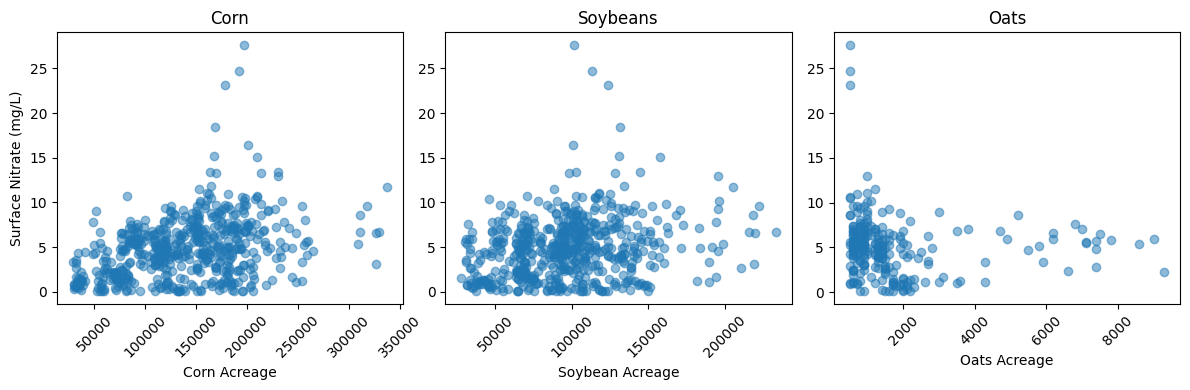

In [25]:
import matplotlib.pyplot as plt

y_col = "surface_nitrate" if "surface_nitrate" in crop_surface.columns else "nitrate"

plt.figure(figsize=(12, 4))

# Corn (exclude 0)
plt.subplot(1, 3, 1)
corn_plot = crop_surface[[corn_col, y_col]].dropna()
corn_plot = corn_plot[corn_plot[corn_col] > 0]

plt.scatter(corn_plot[corn_col], corn_plot[y_col], alpha=0.5)
plt.xlabel("Corn Acreage")
plt.ylabel("Surface Nitrate (mg/L)")
plt.title("Corn")
plt.xticks(rotation=45)

# Soybeans (exclude 0)
plt.subplot(1, 3, 2)
soy_plot = crop_surface[[soy_col, y_col]].dropna()
soy_plot = soy_plot[soy_plot[soy_col] > 0]

plt.scatter(soy_plot[soy_col], soy_plot[y_col], alpha=0.5)
plt.xlabel("Soybean Acreage")
plt.title("Soybeans")
plt.xticks(rotation=45)

# Oats (exclude 0)
oats_cols = [c for c in crop_surface.columns if "OAT" in c.upper()]
if len(oats_cols) > 0:
    oats_col = oats_cols[0]
    plt.subplot(1, 3, 3)

    oats_plot = crop_surface[[oats_col, y_col]].dropna()
    oats_plot = oats_plot[oats_plot[oats_col] > 0]

    plt.scatter(oats_plot[oats_col], oats_plot[y_col], alpha=0.5)
    plt.xlabel("Oats Acreage")
    plt.title("Oats")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("figures/map0_crop_nitrate_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
print("Correlation with surface nitrate:")
print("Corn:", crop_surface[corn_col].corr(crop_surface["nitrate"]))
print("Soybeans:", crop_surface[soy_col].corr(crop_surface["nitrate"]))

if len(oats_cols) > 0:
    print("Oats:", crop_surface[oats_col].corr(crop_surface["nitrate"]))

Correlation with surface nitrate:
Corn: 0.3751661074808686
Soybeans: 0.22967464186291997
Oats: -0.023573562694428386


## Map 1 — Total Crop Acreage (2012 vs 2014 vs 2016)

These three maps show **total planted crop acreage** for each Iowa county in three different years.

Total acreage = Corn + Oats + Soybeans

The main goal here is to compare **where crop production is concentrated** and check if the same counties stay high over time.

To make the comparison fair, all three maps use the **same color scale**.
So if a county becomes darker or lighter from 2012 → 2016, that reflects a real change in total acreage (not just a different legend range).

If a county is grey, it means crop data was missing for that year in our table.

In [27]:
gdf_iowa = gdf_county[gdf_county["STATEFP"] == "19"].copy()
gdf_iowa["county"] = gdf_iowa["NAME"].astype(str).str.strip().str.upper()

In [28]:
years = [2012, 2014, 2016]

check_detail = crop_pivot[crop_pivot["Year"].isin(years)] \
    .groupby("Year")["total_acre"] \
    .agg(["min", "max", "mean", "std"])

print(check_detail)

          min       max      mean           std
Year                                           
2012  62000.0  546500.0  236607.0  89426.953719
2014  48800.0  546000.0  236950.0  89660.720204
2016  43900.0  543500.0  234992.0  89250.616024


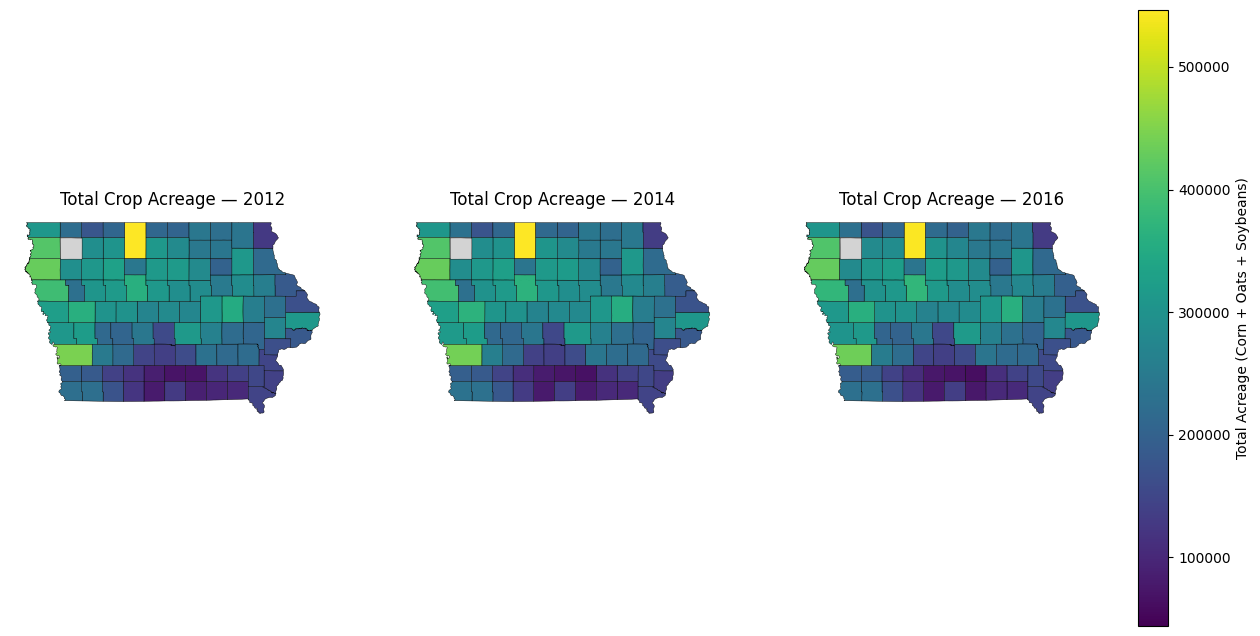

In [29]:
years = [2012, 2014, 2016]

vmin = crop_pivot[crop_pivot["Year"].isin(years)]["total_acre"].min()
vmax = crop_pivot[crop_pivot["Year"].isin(years)]["total_acre"].max()

fig, axes = plt.subplots(1, 3, figsize=(15, 8))

for i, yr in enumerate(years):

    crop_yr = crop_pivot[crop_pivot["Year"] == yr][["County", "total_acre"]].copy()

    gdf_map = gdf_iowa.merge(
        crop_yr,
        left_on="NAME",
        right_on="County",
        how="left"
    )

    gdf_map.plot(
        column="total_acre",
        ax=axes[i],
        vmin=vmin,
        vmax=vmax,
        edgecolor="black",
        linewidth=0.3,
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(f"Total Crop Acreage — {yr}")
    axes[i].axis("off")

sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Total Acreage (Corn + Oats + Soybeans)")


plt.savefig("figures/map1_total_acreage.png", dpi=150, bbox_inches="tight")
plt.show()

This map shows total crop acreage by county in 2012.

Counties with darker shading represent higher total planted acreage,
indicating stronger agricultural activity.

We observe that many central and northern Iowa counties
have particularly high total acreage, reflecting the
state’s concentration of large-scale crop production.

The total acreage maps look very similar because most counties stay high or low every year.

So now we map **percent change** to clearly see which counties increased or decreased over time.

We compute percent change as:

(2016 − 2012) / 2012 × 100

Positive values mean total crop acreage increased from 2012 to 2016.  
Negative values mean total crop acreage decreased.

If a county is missing 2012 or 2016 crop data (or 2012 is zero), we keep it as missing and show it in grey.

In [30]:
crop_2012 = crop_pivot[crop_pivot["Year"] == 2012][["County", "total_acre"]].copy()
crop_2016 = crop_pivot[crop_pivot["Year"] == 2016][["County", "total_acre"]].copy()

crop_2012 = crop_2012.rename(columns={"total_acre": "acre_2012"})
crop_2016 = crop_2016.rename(columns={"total_acre": "acre_2016"})

crop_change = crop_2012.merge(crop_2016, on="County", how="outer")

crop_change["pct_change"] = (crop_change["acre_2016"] - crop_change["acre_2012"]) / crop_change["acre_2012"] * 100
crop_change.loc[crop_change["acre_2012"] <= 0, "pct_change"] = np.nan

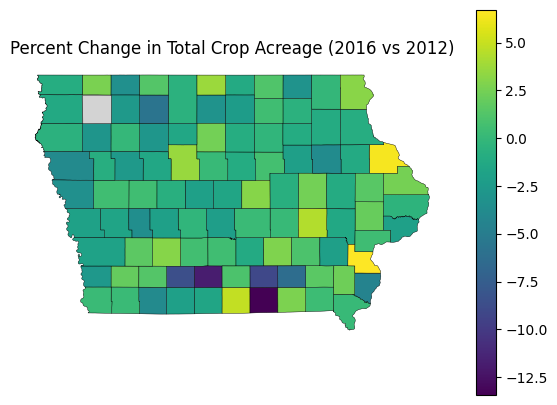

In [31]:
gdf_pct = gdf_iowa.merge(
    crop_change[["County", "pct_change"]],
    left_on="NAME",
    right_on="County",
    how="left"
)

ax = gdf_pct.plot(
    column="pct_change",
    figsize=(7, 5),
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Percent Change in Total Crop Acreage (2016 vs 2012)")
ax.axis("off")

plt.savefig("figures/map1b_acreage_pct_change.png", dpi=150, bbox_inches="tight")
plt.show()

## Map 2 — Where Each Major Crop Is Concentrated (County Averages)

Now we look at the two major crops in Iowa: **Corn** and **Soybeans**.

Instead of picking one year, we take the **average acreage across all years (2010–2017)** for each county.

This gives a more stable picture of where each crop is usually grown.

We make two maps:
- Map 2a: Average corn acreage by county
- Map 2b: Average soybean acreage by county

Darker counties mean higher average planted acreage for that crop.
If a county is missing crop data, it will appear in grey.

In [32]:
corn_avg = crop_pivot.groupby("County")[corn_col].mean().reset_index(name="corn_avg")
soy_avg  = crop_pivot.groupby("County")[soy_col].mean().reset_index(name="soy_avg")

corn_avg["County"] = corn_avg["County"].astype(str).str.strip().str.upper()
soy_avg["County"]  = soy_avg["County"].astype(str).str.strip().str.upper()

gdf_corn = gdf_iowa.merge(corn_avg, left_on="county", right_on="County", how="left")
gdf_soy  = gdf_iowa.merge(soy_avg,  left_on="county", right_on="County", how="left")

gdf_corn["corn_log"] = np.where(gdf_corn["corn_avg"] > 0,
                                np.log10(gdf_corn["corn_avg"]),
                                np.nan)

gdf_soy["soy_log"] = np.where(gdf_soy["soy_avg"] > 0,
                              np.log10(gdf_soy["soy_avg"]),
                              np.nan)

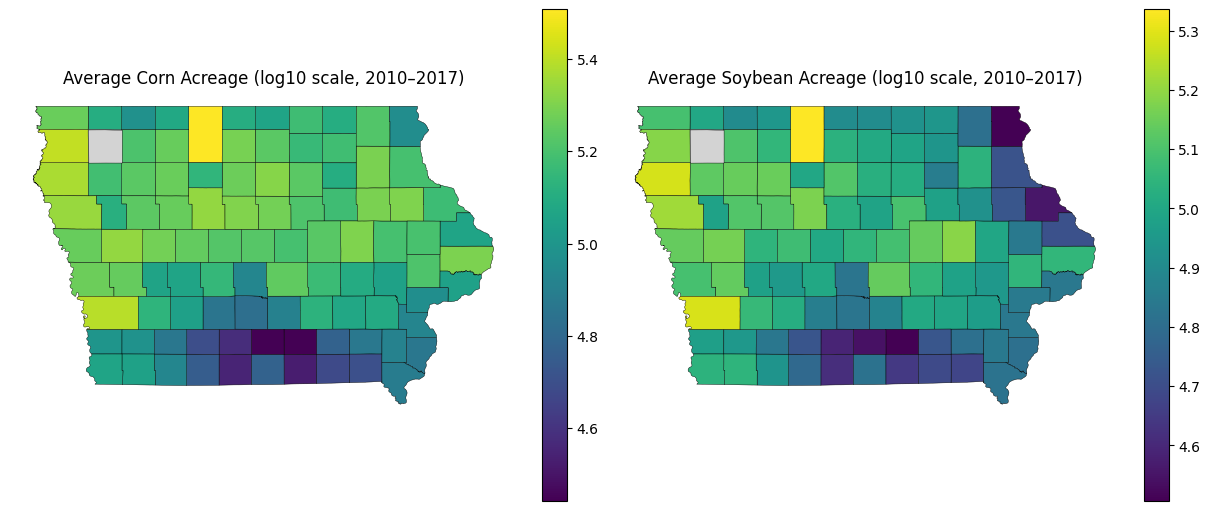

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

gdf_corn.plot(
    column="corn_log",
    ax=axes[0],
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"}
)
axes[0].set_title("Average Corn Acreage (log10 scale, 2010–2017)")
axes[0].axis("off")

gdf_soy.plot(
    column="soy_log",
    ax=axes[1],
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"}
)
axes[1].set_title("Average Soybean Acreage (log10 scale, 2010–2017)")
axes[1].axis("off")

plt.savefig("figures/map2_corn_soy_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

This map shows the percentage of each county’s land area that is planted with corn, oats, and soybeans in 2012.

Counties with darker shading have a higher proportion of land dedicated to agriculture.

Unlike Map 1, this map accounts for county size and highlights areas where farming dominates the landscape.

## Map 3 — Surface Water Nitrate Average by County (2010–2017)

In this section, I map the average surface water nitrate concentration across Iowa counties.

To do this, we:
- Filter surface water measurements to the years 2010–2017.
- Calculate the average nitrate concentration for each county.
- Merge the results with Iowa county boundaries.
- Plot the county-level averages on a choropleth map.

This allows us to see whether nitrate contamination shows any spatial pattern across the state.

Missing counties (no data): 7
Missing counties: ['Cedar', 'Pocahontas', 'Jefferson', 'Wright', 'Grundy', 'Davis', 'Winnebago']


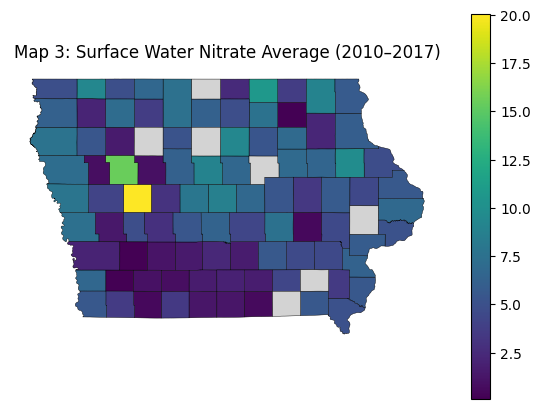

In [34]:

gdf_water_yr = gdf_water[
    (gdf_water["year"] >= 2010) &
    (gdf_water["year"] <= 2017)
].copy()


surface_avg = (
    gdf_water_yr.groupby("NAME")["nitrate"]
    .mean()
    .reset_index()
)


gdf_map3 = gdf_iowa.merge(surface_avg, on="NAME", how="left")

print("Missing counties (no data):", gdf_map3["nitrate"].isna().sum())
missing_names = gdf_map3.loc[gdf_map3["nitrate"].isna(), "NAME"].tolist()
print("Missing counties:", missing_names)


ax = gdf_map3.plot(
    column="nitrate",
    figsize=(7, 5),
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Map 3: Surface Water Nitrate Average (2010–2017)")
ax.axis("off")
plt.savefig("figures/map3_surface_nitrate_avg.png", dpi=150, bbox_inches="tight")
plt.show()



This map shows the average surface water nitrate concentration by county from 2010–2017.

- Counties with darker colors indicate higher average nitrate levels.
- Grey counties represent locations where no surface water nitrate data were available during 2010–2017.

We observe that nitrate levels vary across the state rather than being uniformly distributed. Some counties show noticeably higher average concentrations, suggesting possible regional patterns in nutrient runoff.

In the next step, we will compare these spatial nitrate patterns with crop acreage to examine whether agricultural intensity may be related to nitrate contamination.

## Map 4 — Time Series of Nitrate Concentration (2010–2017)

In this section, I examine how nitrate concentrations change over time across Iowa.

To do this, I calculate the statewide yearly average nitrate concentration for:

- Surface water (rivers and streams)
- Groundwater (wells)

For each year from 2010 to 2017, I compute the mean nitrate concentration across all available measurements in that year.

This allows us to compare temporal trends between surface water and groundwater.

In [35]:

surface_year = (
    gdf_water[(gdf_water["year"] >= 2010) & (gdf_water["year"] <= 2017)]
    .groupby("year")["nitrate"]
    .mean()
    .reset_index()
)


ground_year = (
    ground_county_year[(ground_county_year["year"] >= 2010) & (ground_county_year["year"] <= 2017)]
    .groupby("year")["nitrate"]
    .mean()
    .reset_index()
)

surface_year, ground_year

(   year   nitrate
 0  2010  6.076152
 1  2011  6.058912
 2  2012  4.136765
 3  2013  7.387267
 4  2014  5.201736
 5  2015  6.543458
 6  2016  7.197125
 7  2017  6.127151,
    year   nitrate
 0  2010  9.731278
 1  2011  9.044788
 2  2012  4.553428
 3  2013  5.233054
 4  2014  3.808824
 5  2015  5.448710
 6  2016  6.843238
 7  2017  1.300000)

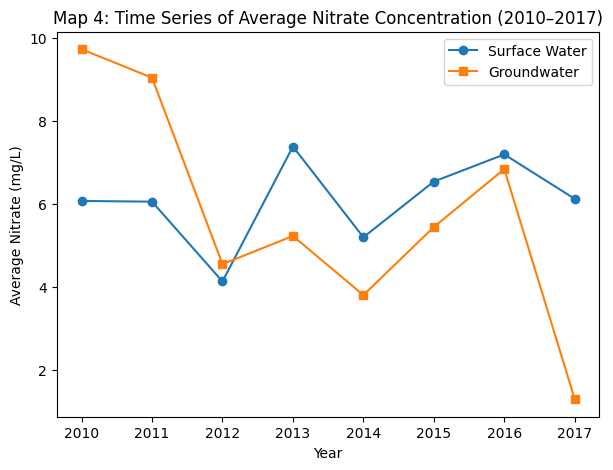

In [36]:
plt.figure(figsize=(7, 5))

plt.plot(surface_year["year"], surface_year["nitrate"], marker="o", label="Surface Water")
plt.plot(ground_year["year"], ground_year["nitrate"], marker="s", label="Groundwater")

plt.xlabel("Year")
plt.ylabel("Average Nitrate (mg/L)")
plt.title("Map 4: Time Series of Average Nitrate Concentration (2010–2017)")
plt.legend()

plt.savefig("figures/map4_time_series.png", dpi=150, bbox_inches="tight")
plt.show()



This time series shows year-to-year variation in nitrate concentrations from 2010–2017.

Surface water nitrate levels fluctuate moderately over time, with noticeable increases in 2013 and 2016. Groundwater nitrate levels show a similar general pattern but differ in magnitude across years.

In 2010–2011, groundwater nitrate appears higher than surface water, while in later years the two become more similar. The sharp decline in groundwater nitrate in 2017 may reflect fewer measurements, changes in sampling locations, or environmental conditions that year.

Overall, the two lines suggest that surface and groundwater nitrate concentrations respond differently over time, possibly due to differences in runoff dynamics versus subsurface transport and storage.

## Map 5 — Bivariate Map: Crop Intensity and Nitrate Together

So far, we have looked at crop acreage and nitrate levels separately.

But in reality, these two things are connected.

Instead of plotting them one by one, now we combine both variables in one map.

The goal is simple:
We want to see whether counties that grow more crops also show higher nitrate levels.

To do this clearly, we classify counties into four groups:

- High crop + High nitrate  
- High crop + Low nitrate  
- Low crop + High nitrate  
- Low crop + Low nitrate  

This helps us move from just “seeing patterns” to actually testing a spatial relationship.

If many counties fall into the “High crop + High nitrate” category,
that strengthens the idea that agricultural intensity may be linked to water quality.

This is a more advanced spatial analysis because we are comparing two variables at the same time instead of one.

In [37]:
bi_df = master_df.groupby("County")[["intensity_acre", "surface_nitrate"]].mean().reset_index()
bi_df["County"] = bi_df["County"].astype(str).str.strip().str.upper()

bi_df = bi_df.dropna(subset=["surface_nitrate"])

crop_median = bi_df["intensity_acre"].median()
nitrate_median = bi_df["surface_nitrate"].median()

bi_df["crop_level"] = np.where(bi_df["intensity_acre"] >= crop_median, "High Crop", "Low Crop")
bi_df["nitrate_level"] = np.where(bi_df["surface_nitrate"] >= nitrate_median, "High Nitrate", "Low Nitrate")

bi_df["category"] = bi_df["crop_level"] + " + " + bi_df["nitrate_level"]

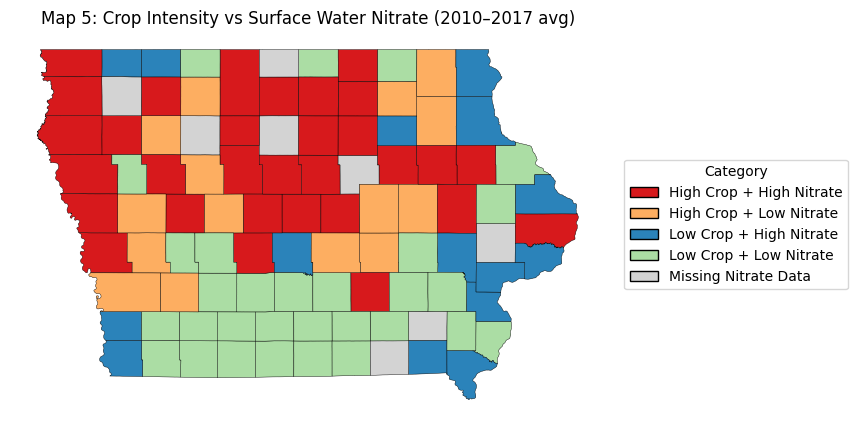

In [38]:
gdf_bi = gdf_iowa.merge(
    bi_df[["County", "category"]],
    left_on="county",
    right_on="County",
    how="left"
)

color_dict = {
    "High Crop + High Nitrate": "#d7191c",
    "High Crop + Low Nitrate": "#fdae61",
    "Low Crop + High Nitrate": "#2b83ba",
    "Low Crop + Low Nitrate": "#abdda4"
}

gdf_bi["color"] = gdf_bi["category"].map(color_dict)
gdf_bi["color"] = gdf_bi["color"].fillna("lightgrey")

from matplotlib.patches import Patch

fig, ax = plt.subplots(1, 1, figsize=(9, 5))

gdf_bi.plot(
    color=gdf_bi["color"],
    ax=ax,
    edgecolor="black",
    linewidth=0.3
)

ax.set_title("Map 5: Crop Intensity vs Surface Water Nitrate (2010–2017 avg)")
ax.axis("off")

legend_elements = [
    Patch(facecolor="#d7191c", edgecolor="black", label="High Crop + High Nitrate"),
    Patch(facecolor="#fdae61", edgecolor="black", label="High Crop + Low Nitrate"),
    Patch(facecolor="#2b83ba", edgecolor="black", label="Low Crop + High Nitrate"),
    Patch(facecolor="#abdda4", edgecolor="black", label="Low Crop + Low Nitrate"),
    Patch(facecolor="lightgrey", edgecolor="black", label="Missing Nitrate Data")
]

ax.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Category"
)

plt.savefig("figures/map5_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()

## Map 6 — Groundwater Exceedance Frequency (> 10 mg/L) (2010–2017)

Here we measure a human-health style threshold: **how often does groundwater nitrate exceed 10 mg/L** (common drinking-water standard).

For each county, we:
1. take all groundwater nitrate samples (2010–2017)
2. mark each sample as **exceed = 1** if nitrate > 10 mg/L, else **0**
3. average exceed values inside each county

So the final number is a **frequency (0 to 1)**:
- 0.00 = never exceeded
- 0.25 = exceeded in 25% of samples
- 1.00 = always exceeded

In [39]:
ground_exceed = gdf_ground[(gdf_ground["year"] >= 2010) & (gdf_ground["year"] <= 2017)].copy()

ground_exceed["exceed"] = (ground_exceed["nitrate"] > 10).astype(int)

exceed_county = (
    ground_exceed.groupby("NAME")["exceed"]
    .mean()
    .reset_index()
    .rename(columns={"exceed": "exceed_freq"})
)

exceed_county.head()

,NAME,exceed_freq
0,Allamakee,0.0
1,Audubon,0.0
2,Benton,0.0
3,Black Hawk,0.0
4,Boone,0.0


In [40]:
gdf_map7 = gdf_iowa.merge(
    exceed_county,
    on="NAME",
    how="left"
)

gdf_map7["exceed_freq"].isna().sum()

np.int64(59)

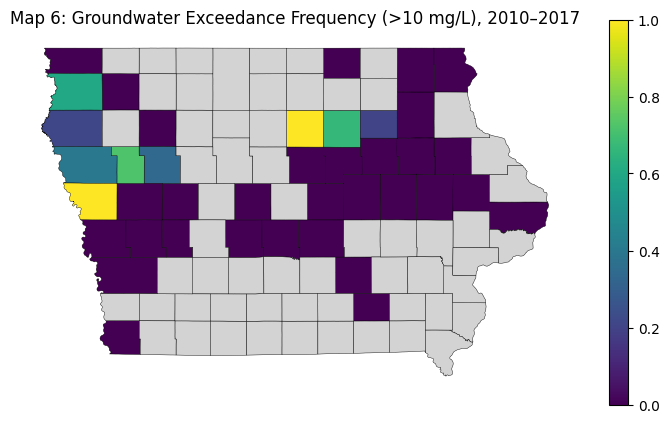

In [41]:
ax = gdf_map7.plot(
    column="exceed_freq",
    figsize=(9, 5),
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Map 6: Groundwater Exceedance Frequency (>10 mg/L), 2010–2017")
ax.axis("off")
plt.savefig("figures/map6_groundwater_exceedance.png", dpi=150, bbox_inches="tight")
plt.show()

**Grey counties** mean we did not have enough groundwater nitrate samples with usable coordinates in that county (2010–2017), so we cannot compute an exceedance frequency there.

## Map 7 — Surface Water Nitrate Trend (2010–2017)

Instead of comparing only two years, we calculate the trend
using all available data from 2010 to 2017.

For each county, we fit a simple linear regression:

nitrate = a + b × year

The slope (b) represents the annual rate of change.

Positive slope:
• nitrate increasing over time

Negative slope:
• nitrate decreasing over time

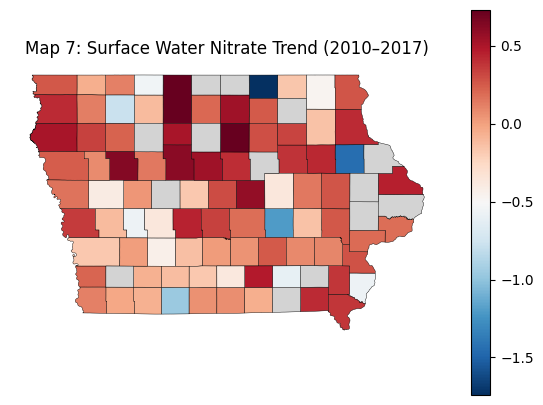

In [42]:
sw_trend_data = water_county_year[
    (water_county_year["year"] >= 2010) &
    (water_county_year["year"] <= 2017)
].copy()

def compute_slope(df):
    if df["year"].nunique() < 3:
        return np.nan
    return np.polyfit(df["year"], df["nitrate"], 1)[0]

trend_sw = (
    sw_trend_data
    .groupby("NAME")
    .apply(compute_slope, include_groups=False)
    .reset_index(name="trend")
)

trend_sw["county"] = trend_sw["NAME"].astype(str).str.strip().str.upper()

gdf_map8 = gdf_iowa.merge(trend_sw[["county", "trend"]], on="county", how="left")

ax = gdf_map8.plot(
    column="trend",
    cmap="RdBu_r",
    figsize=(7, 5),
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title("Map 7: Surface Water Nitrate Trend (2010–2017)")
ax.axis("off")
plt.savefig("figures/map7_nitrate_trend.png", dpi=150, bbox_inches="tight")
plt.show()

### What This Map Shows

-  **Red counties** indicate that surface water nitrate increased between 2010 and 2017.  
-  **Blue counties** indicate that surface water nitrate decreased over the same period.  
- Lighter or near-white areas represent little to no change in nitrate concentration.  
- Grey counties indicate that nitrate data was not available for either 2010 or 2017, so change could not be calculated.

## Map 8 — Surface vs Groundwater Nitrate Comparison (2010–2017)

In this section, we compare county-level surface water nitrate
with groundwater nitrate.

We merge county–year averages (2010–2017) for:

• Surface water nitrate  
• Groundwater nitrate  

Each point in the scatter plot represents one county in one year.

If the points follow a positive pattern, this suggests that
counties with high surface nitrate also tend to have high
groundwater nitrate.

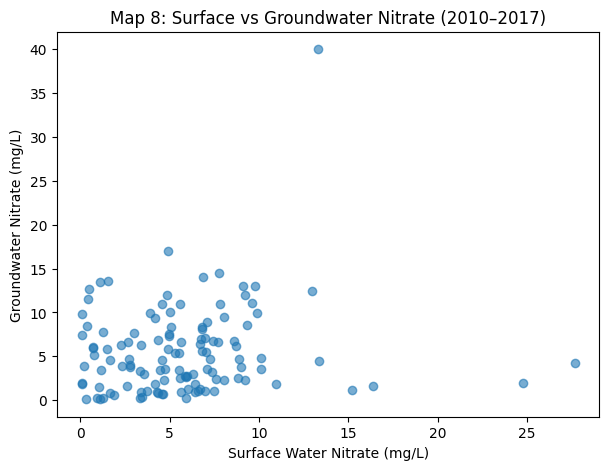

In [43]:
surface_county_year = water_county_year.copy()

surface_county_year = water_county_year.copy()

surface_county_year["NAME"] = surface_county_year["NAME"].astype(str).str.strip().str.upper()
ground_county_year["NAME"] = ground_county_year["NAME"].astype(str).str.strip().str.upper()

surface_county_year["year"] = pd.to_numeric(surface_county_year["year"], errors="coerce").astype("Int64")
ground_county_year["year"] = pd.to_numeric(ground_county_year["year"], errors="coerce").astype("Int64")

compare_sw_gw = surface_county_year.merge(
    ground_county_year,
    on=["NAME", "year"],
    how="inner",
    suffixes=("_surface", "_ground")
)

compare_sw_gw.head()

plt.figure(figsize=(7, 5))
plt.scatter(compare_sw_gw["nitrate_surface"], compare_sw_gw["nitrate_ground"], alpha=0.6)
plt.xlabel("Surface Water Nitrate (mg/L)")
plt.ylabel("Groundwater Nitrate (mg/L)")
plt.title("Map 8: Surface vs Groundwater Nitrate (2010–2017)")
plt.savefig("figures/map8_surface_vs_groundwater.png", dpi=150, bbox_inches="tight")
plt.show()

# Map 9 — County-Level Correlation Between Agricultural Intensity and Surface Water Nitrate




To move beyond visual inspection of scatterplots, we compute the Pearson correlation coefficient between agricultural intensity and surface water nitrate concentration for each county across the study period (2010–2017).

This approach allows us to examine whether changes in agricultural intensity within a county over time are associated with changes in nitrate concentration.

Correlation values range from:

- **+1** - strong positive relationship  
- **0** - no linear relationship  
- **−1** - strong negative relationship  

By mapping these values, we can assess whether the intensity–nitrate relationship is spatially consistent across Iowa or varies by region.

In [44]:

df_surface = master_df.dropna(subset=["intensity_acre", "surface_nitrate"])
df_ground = master_df.dropna(subset=["intensity_acre", "ground_nitrate"])


corr_surface = df_surface["intensity_acre"].corr(df_surface["surface_nitrate"])
corr_ground = df_ground["intensity_acre"].corr(df_ground["ground_nitrate"])

print("Overall Correlation (Intensity vs Surface Nitrate):", round(corr_surface, 3))
print("Overall Correlation (Intensity vs Groundwater Nitrate):", round(corr_ground, 3))

Overall Correlation (Intensity vs Surface Nitrate): 0.332
Overall Correlation (Intensity vs Groundwater Nitrate): 0.242


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


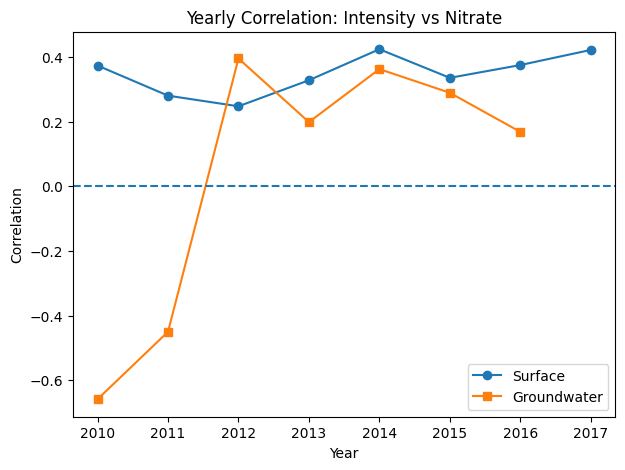

In [45]:
year_corr_surface = (
    master_df.dropna(subset=["intensity_acre", "surface_nitrate"])
    .groupby("Year")
    .apply(lambda x: x["intensity_acre"].corr(x["surface_nitrate"]), include_groups=False)
)

year_corr_ground = (
    master_df.dropna(subset=["intensity_acre", "ground_nitrate"])
    .groupby("Year")
    .apply(lambda x: x["intensity_acre"].corr(x["ground_nitrate"]), include_groups=False)
)

plt.figure(figsize=(7,5))
plt.plot(year_corr_surface.index, year_corr_surface.values, marker='o', label="Surface")
plt.plot(year_corr_ground.index, year_corr_ground.values, marker='s', label="Groundwater")

plt.axhline(0, linestyle='--')
plt.xlabel("Year")
plt.ylabel("Correlation")
plt.title("Yearly Correlation: Intensity vs Nitrate")
plt.legend()
plt.show()

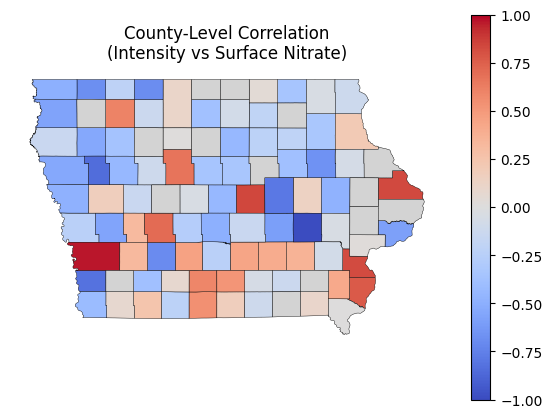

In [46]:
def county_corr(group, nitrate_col):
    if group[nitrate_col].notna().sum() >= 3:
        return group["intensity_acre"].corr(group[nitrate_col])
    else:
        return None

county_corr_surface = (
    master_df.groupby("County")
    .apply(lambda x: county_corr(x, "surface_nitrate"), include_groups=False)
    .reset_index(name="corr_surface")
)

gdf_corr_surface = gdf_iowa.merge(
    county_corr_surface,
    left_on="NAME",
    right_on="County",
    how="left"
)

ax = gdf_corr_surface.plot(
    column="corr_surface",
    cmap="coolwarm",
    legend=True,
    vmin=-1,
    vmax=1,
    edgecolor="black",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey"},
    figsize=(7,5)
)

ax.set_title("County-Level Correlation\n(Intensity vs Surface Nitrate)")
ax.axis("off")
plt.savefig("figures/map9_county_correlation.png", dpi=150, bbox_inches="tight")
plt.show()



Several counties exhibit positive correlation values (orange to red), indicating that increases in agricultural intensity over time are associated with increases in nitrate concentration. These positive associations are more common in central and southern regions of the state.

Other counties show weak or near-zero correlation (light colors), suggesting limited linear association between intensity and nitrate trends during the study period.

A smaller number of counties display negative correlations (blue shades), meaning that nitrate concentrations did not increase alongside agricultural intensity. This suggests that additional factors—such as rainfall variability, watershed characteristics, drainage systems, or monitoring density—may influence nitrate dynamics in those areas.

Overall, the map supports the presence of a positive association in many counties, but also highlights that the relationship is not uniform across Iowa. Agricultural intensity appears to be an important contributor to surface water nitrate, though it is not the sole determining factor.

It is important to note that correlation does not imply causation; this analysis identifies statistical association rather than direct causal impact.

## Map 10 — Distribution of Nitrate Concentrations (2010–2017)

This figure shows the distribution of nitrate concentrations
for surface water and groundwater samples between 2010 and 2017.

Histograms help us understand:

• Typical nitrate levels  
• Spread (variability)  
• Presence of extreme values  
• Whether groundwater tends to have higher concentrations

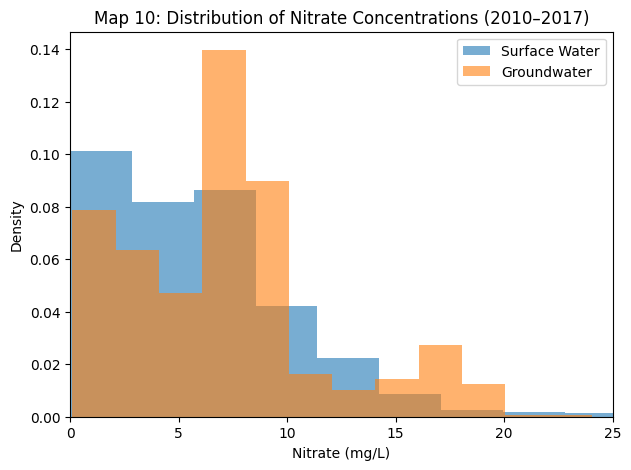

In [47]:
plt.figure(figsize=(7, 5))

plt.hist(
    gdf_water_yr["nitrate"],
    bins=20,
    alpha=0.6,
    density=True,
    label="Surface Water"
)

plt.hist(
    gdf_ground["nitrate"],
    bins=20,
    alpha=0.6,
    density=True,
    label="Groundwater"
)

plt.xlabel("Nitrate (mg/L)")
plt.ylabel("Density")
plt.title("Map 10: Distribution of Nitrate Concentrations (2010–2017)")
plt.legend()
plt.xlim(0, 25)
plt.savefig("figures/map10_nitrate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Map 11 — Nitrate by Crop Intensity Category (2010–2017)

In this section, we examine whether counties with higher crop acreage
also tend to have higher nitrate concentrations.

We classify counties into three crop intensity groups based on
total crop acreage:

• Low intensity  
• Medium intensity  
• High intensity  

We then compare surface water nitrate concentrations using boxplots.

If agriculture influences nitrate levels, we expect higher intensity
counties to show higher median nitrate concentrations.

<Figure size 700x500 with 0 Axes>

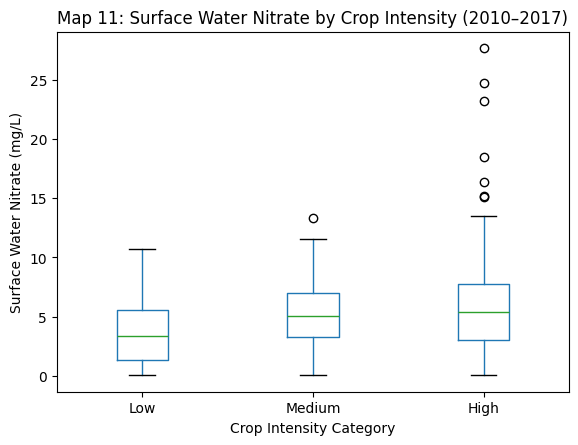

In [48]:
crop_df = crop_pivot[(crop_pivot["Year"] >= 2010) & (crop_pivot["Year"] <= 2017)].copy()

crop_df["County"] = crop_df["County"].astype(str).str.strip().str.upper()
surface_county_year["NAME"] = surface_county_year["NAME"].astype(str).str.strip().str.upper()

for col in ["CORN", "SOYBEANS", "OATS"]:
    if col not in crop_df.columns:
        crop_df[col] = 0

crop_df["total_acre"] = crop_df["CORN"] + crop_df["SOYBEANS"] + crop_df["OATS"]


box_df = crop_df.merge(
    surface_county_year,
    left_on=["County", "Year"],
    right_on=["NAME", "year"],
    how="inner"
)


box_df = box_df.dropna(subset=["total_acre", "nitrate"])

box_df["intensity"] = pd.qcut(
    box_df["total_acre"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

plt.figure(figsize=(7, 5))

box_df.boxplot(column="nitrate", by="intensity", grid=False)

plt.xlabel("Crop Intensity Category")
plt.ylabel("Surface Water Nitrate (mg/L)")
plt.title("Map 11: Surface Water Nitrate by Crop Intensity (2010–2017)")
plt.suptitle("")
plt.savefig("figures/map11_nitrate_by_intensity.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation of Map 11

The boxplot shows that median nitrate concentrations increase
from Low → Medium → High crop intensity counties.

High intensity counties also show greater variability and
several extreme outliers above 20 mg/L.

This suggests that counties with larger agricultural acreage
tend to experience higher surface water nitrate levels,
although the relationship is moderate rather than extremely strong.

## Limitations

- Correlation does not imply causation.
- Nitrate measurements are unevenly distributed across counties.
- Surface water responds rapidly, groundwater responds slowly.
- Agricultural intensity is measured using acreage, not fertilizer application rates.
- Other factors (rainfall, soil type, drainage systems) are not controlled for.

## Conclusions

This project examined whether agricultural intensity is associated with nitrate contamination across Iowa counties from 2010–2017.

Key findings include:

- Nitrate concentrations vary spatially across counties.
- Surface water shows more year-to-year variability than groundwater.
- Counties with higher crop acreage tend to show moderately higher nitrate concentrations.
- Groundwater exceedances of the EPA 10 mg/L standard occur in certain regions.

Overall, the results suggest that agricultural intensity likely contributes to nitrate contamination, though other environmental and hydrological factors also play a role.

Future work could incorporate fertilizer application data, precipitation patterns, or more advanced statistical modeling to better isolate causal mechanisms.

## References

U.S. Geological Survey (USGS). (2010). *Nutrients in the Nation’s streams and groundwater* (Fact Sheet 2010–3078). https://pubs.usgs.gov/fs/2010/3078/

Iowa Nutrient Reduction Strategy. (2013). *Iowa Nutrient Reduction Strategy*. https://www.nutrientstrategy.iastate.edu/sites/default/files/documents/NRS1-141001.pdf

Electronic Code of Federal Regulations (eCFR). (n.d.). *40 CFR § 141.62 Maximum contaminant levels for inorganic contaminants* (Nitrate MCL = 10 mg/L as nitrogen). Accessed 2026-03-02. https://www.ecfr.gov/current/title-40/chapter-I/subchapter-D/part-141/subpart-G/section-141.62

Vedachalam, S. (2018). *Source Water Quality and the Cost of Nitrate Treatment in the Mississippi River Basin* (analysis period: Jan 2008–Dec 2017). https://www.google.com/url?q=https%3A%2F%2Fwww.nemw.org%2Fwp-content%2Fuploads%2F2018%2F05%2FNEMWI_WaterQuality_NitrateCost_2018.pdf

Water Quality Portal. (n.d.). *WaterQualityData.us* (data access portal integrating USGS/EPA/partner water-quality monitoring data). Accessed 2026-03-02.https://www.waterqualitydata.us/